In [6]:
import basedosdados as bd
import pandas as pd

In [7]:
project_id = "teste-ic-fairness"
query = """
SELECT
  d.id_inscricao,
  d.cor_raca,
  d.ensino,
  d.estado_civil,
  d.nota_matematica,
  d.sexo,
  d.sigla_uf_prova,
  d.tipo_escola,
  q.q006 AS renda_familiar,
  q.q025 AS tem_internet,
FROM
  `basedosdados.br_inep_enem.microdados` as d

INNER JOIN `basedosdados.br_inep_enem.questionario_socioeconomico_2023` as q
  ON q.id_inscricao = d.id_inscricao

WHERE d.ano = 2023
AND d.nota_matematica IS NOT NULL
AND d.ensino IS NOT NULL
AND d.sigla_uf_prova IS NOT NULL
LIMIT 20000;
"""

# df = bd.read_sql(query, billing_project_id=project_id)
# df.to_csv('dataset.csv', index=False)

df = pd.read_csv('dataset.csv')

print(df)


       id_inscricao  cor_raca  ensino  estado_civil  nota_matematica sexo  \
0      210059134967         1       1             1            521.6    M   
1      210059582187         3       1             1            432.0    F   
2      210059260231         3       1             1            494.4    M   
3      210059658231         3       1             1            553.9    F   
4      210059753677         3       1             1            334.8    F   
...             ...       ...     ...           ...              ...  ...   
19995  210058612688         2       1             1            429.4    F   
19996  210059224383         1       1             0            344.3    F   
19997  210058326464         2       1             1            586.4    M   
19998  210059342414         3       1             1            361.6    M   
19999  210059617158         3       1             1            467.3    F   

      sigla_uf_prova  tipo_escola renda_familiar tem_internet  
0          

In [8]:
df[df.notnull().all(1)]

,id_inscricao,cor_raca,ensino,estado_civil,nota_matematica,sexo,sigla_uf_prova,tipo_escola,renda_familiar,tem_internet
0,210059134967,1,1,1,521.6,M,RR,2,B,B
1,210059582187,3,1,1,432.0,F,RR,2,C,B
2,210059260231,3,1,1,494.4,M,RR,2,F,B
3,210059658231,3,1,1,553.9,F,RR,2,C,B
4,210059753677,3,1,1,334.8,F,RR,2,B,B
...,...,...,...,...,...,...,...,...,...,...
19995,210058612688,2,1,1,429.4,F,TO,2,B,A
19996,210059224383,1,1,0,344.3,F,TO,2,A,B
19997,210058326464,2,1,1,586.4,M,TO,2,C,B
19998,210059342414,3,1,1,361.6,M,TO,2,G,B


In [9]:
df.head(50)

,id_inscricao,cor_raca,ensino,estado_civil,nota_matematica,sexo,sigla_uf_prova,tipo_escola,renda_familiar,tem_internet
0,210059134967,1,1,1,521.6,M,RR,2,B,B
1,210059582187,3,1,1,432.0,F,RR,2,C,B
2,210059260231,3,1,1,494.4,M,RR,2,F,B
3,210059658231,3,1,1,553.9,F,RR,2,C,B
4,210059753677,3,1,1,334.8,F,RR,2,B,B
5,210059651737,0,1,1,401.7,M,RR,2,B,B
6,210059854549,3,1,1,355.6,F,RR,2,B,B
7,210060237917,3,1,1,420.4,F,RR,2,B,B
8,210061845856,5,1,1,428.6,M,RR,2,A,A
9,210059571154,3,1,1,727.2,F,RR,2,G,B


In [10]:
df.describe()

,id_inscricao,cor_raca,ensino,estado_civil,nota_matematica,tipo_escola
count,2.000000e+04,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,2.100599e+11,2.098000,1.006550,0.972900,495.562275,2.083450
std,1.132515e+06,0.992394,0.080669,0.272891,111.965733,0.276568
min,2.100580e+11,0.000000,1.000000,0.000000,0.000000,2.000000
25%,2.100588e+11,1.000000,1.000000,1.000000,411.400000,2.000000
50%,2.100599e+11,2.000000,1.000000,1.000000,481.700000,2.000000
75%,2.100608e+11,3.000000,1.000000,1.000000,571.400000,2.000000
max,2.100621e+11,5.000000,2.000000,4.000000,927.100000,3.000000


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id_inscricao     20000 non-null  int64  
 1   cor_raca         20000 non-null  int64  
 2   ensino           20000 non-null  int64  
 3   estado_civil     20000 non-null  int64  
 4   nota_matematica  20000 non-null  float64
 5   sexo             20000 non-null  object 
 6   sigla_uf_prova   20000 non-null  object 
 7   tipo_escola      20000 non-null  int64  
 8   renda_familiar   20000 non-null  object 
 9   tem_internet     20000 non-null  object 
dtypes: float64(1), int64(5), object(4)
memory usage: 1.5+ MB


In [12]:
df.nunique()

id_inscricao       20000
cor_raca               6
ensino                 2
estado_civil           5
nota_matematica     4196
sexo                   2
sigla_uf_prova        27
tipo_escola            2
renda_familiar        17
tem_internet           2
dtype: int64

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns


# sns.scatterplot(
#     x='sexo',
#     y='nota_matematica',
#     alpha=0.7,
#     data=df,
# )

# dataX = df.groupby('nota_matematica')['sexo'].value_counts()
# plt.figure(figsize=(8, 5))
# plt.hist(dataX, color='#ff5a32', edgecolor='black')

# plt.show()

# dataX

# df.hist(figsize=(20, 20), bins=25)

In [14]:
mapa_raca = {
    "0": 'Não Declarado',
    "1": 'Branca',
    "2": 'Preta',
    "3": 'Parda',
    "4": 'Amarela',
    "5": 'Indígena'
}

mapa_escola = {
    "1": 'Não Respondido',
    "2": 'Pública',
    "3": 'Privada'
}

mapa_internet = {'A': 'Não', 'B': 'Sim'}

# Substituindo no DataFrame
df_visualizacao = df.copy()
df_visualizacao['cor_raca'] = df_visualizacao['cor_raca'].map(mapa_raca)
df_visualizacao['tipo_escola'] = df_visualizacao['tipo_escola'].map(mapa_escola)
df_visualizacao['tem_internet'] = df_visualizacao['tem_internet'].map(mapa_internet)

df_visualizacao.head(10)

# Esse dataFrame facilita a visualização de alguns dados, como raça, tipo da escola, que são atributos importantes.

,id_inscricao,cor_raca,ensino,estado_civil,nota_matematica,sexo,sigla_uf_prova,tipo_escola,renda_familiar,tem_internet
0,210059134967,NaN,1,1,521.6,M,RR,NaN,B,Sim
1,210059582187,NaN,1,1,432.0,F,RR,NaN,C,Sim
2,210059260231,NaN,1,1,494.4,M,RR,NaN,F,Sim
3,210059658231,NaN,1,1,553.9,F,RR,NaN,C,Sim
4,210059753677,NaN,1,1,334.8,F,RR,NaN,B,Sim
5,210059651737,NaN,1,1,401.7,M,RR,NaN,B,Sim
6,210059854549,NaN,1,1,355.6,F,RR,NaN,B,Sim
7,210060237917,NaN,1,1,420.4,F,RR,NaN,B,Sim
8,210061845856,NaN,1,1,428.6,M,RR,NaN,A,Não
9,210059571154,NaN,1,1,727.2,F,RR,NaN,G,Sim


In [15]:
df[df['id_inscricao'].duplicated()]

,id_inscricao,cor_raca,ensino,estado_civil,nota_matematica,sexo,sigla_uf_prova,tipo_escola,renda_familiar,tem_internet


In [16]:
df_visualizacao[df_visualizacao['tipo_escola'] == "Privada"].count()

# podemos ver que a minoria dos alunos é de escola particular (o que seria uma vantagem)

id_inscricao       0
cor_raca           0
ensino             0
estado_civil       0
nota_matematica    0
sexo               0
sigla_uf_prova     0
tipo_escola        0
renda_familiar     0
tem_internet       0
dtype: int64

In [17]:
dataEscola = df_visualizacao.groupby('tipo_escola')['nota_matematica'].mean().sort_values(ascending=False)
dataEscola

# aqui vemos também que a escola pública tem uma nota máxima maior em matemática do que a escola privada
# contudo, a privada tem uma média de quase 100 pontos maior que a pública

Series([], Name: nota_matematica, dtype: float64)

In [18]:
dataGender = df_visualizacao.groupby('sexo')['nota_matematica'].mean().sort_values(ascending=False)
dataGender

# vemos que a máxima feminina é maior que a máxima masculina
# porém a média masculina é maior que a feminina

sexo
M    518.364503
F    484.465405
Name: nota_matematica, dtype: float64

In [19]:
dataRenda = df_visualizacao.groupby('renda_familiar')['nota_matematica'].mean().sort_values(ascending=False)
dataRenda

# rendas maiores tendém a irem melhores. A renda Q (> 20 sslários minímos) tem o segundo maior máximo e a maior média
# enquanto a renda A (sem renda) tem a pior média e máxima

renda_familiar
Q    629.678082
O    621.511111
P    619.365385
N    609.361194
M    601.961039
K    585.930968
L    578.168354
I    573.103716
J    569.224868
H    564.779775
G    551.054991
F    535.684634
E    519.351216
D    510.461306
C    495.713613
B    467.174334
A    442.782423
Name: nota_matematica, dtype: float64

In [20]:
dataRace = df_visualizacao.groupby('cor_raca')['nota_matematica'].mean().sort_values(ascending=False)
dataRace

Series([], Name: nota_matematica, dtype: float64)

In [21]:
dataState = df_visualizacao.groupby('sigla_uf_prova')['nota_matematica'].mean().sort_values(ascending=False)
dataState

sigla_uf_prova
MG    520.319875
SP    519.485774
RS    517.922622
SC    517.808383
RJ    512.172330
PR    506.935929
CE    506.522524
ES    503.348997
DF    497.921864
GO    494.862565
PE    493.124596
RR    491.673810
MS    490.350183
RO    487.199394
RN    486.804091
PB    486.366667
BA    483.163942
MT    476.912968
PI    471.534281
SE    470.618045
AL    465.101087
TO    462.084977
PA    459.772296
MA    459.666927
AP    450.634161
AM    449.821542
AC    446.813043
Name: nota_matematica, dtype: float64

In [22]:
dataNet = df_visualizacao.groupby('tem_internet')['nota_matematica'].mean().sort_values(ascending=False)
dataNet

tem_internet
Sim    500.729079
Não    450.541574
Name: nota_matematica, dtype: float64

#### Regressão

Vamos começar com um modelo de Regressão para tentar prever (ou aproximar) a nota da prova de matemática de um aluno que participou do ENEM no ano de 2023. 
<br><br>
O target Y, logicamente, é a nota na prova de matemática.<br>
As outras colunas representam os features (exceto id_inscricao)

Vamos começar com um modelo simples, como um Linear Regression.\
<b>Ainda não iremos calcular métricas de fairness</b>.

In [23]:
# Como no dataset temos diversos valores que são strings, posso usar OneHot Encoder para alguns features com poucas opções, como genero,
# tipo_escola, tem_internet e ensinom que possuem apenas 2 opções
# Para atributos progressivos como renda familiar, podemos considerar um Ordinal Encoder.

# Para atributos como a renda, que possui diversas categorias, talvez um TargetEncoder possa ser útil

from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, TargetEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score

import numpy as np

np.random.seed(42)

X = df.drop(['nota_matematica', 'id_inscricao'], axis=1)
y = df['nota_matematica']

label_values = ['renda_familiar']
oh_values = ['tipo_escola', 'tem_internet', 'sexo', 'ensino', 'cor_raca', 'estado_civil', 'sigla_uf_prova']
# target_encoder_values = []

full_pipeline = ColumnTransformer(
    transformers=[
        ('label_val', OrdinalEncoder(), label_values),
        ('oh', OneHotEncoder(handle_unknown='ignore'), oh_values),
        # ('target_val', TargetEncoder(), target_encoder_values)
    ],
    remainder='drop',
)

linear_regression_model_pipeline = Pipeline([
    ('preprocessor', full_pipeline),
    ('model', LinearRegression()),
])

splitDf = KFold(random_state=42, shuffle=True)

total_mae = 0
total_rmse = 0
total_r2 = 0
for i, (train_index, test_index) in enumerate(splitDf.split(X)):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    linear_regression_model_pipeline.fit(X_train, y_train)

    # print(f"Treinando no fold {i + 1}")

    preds = linear_regression_model_pipeline.predict(X_test)

    mae = mean_absolute_error(y_test, preds)
    total_mae += mae
    # print(f"MAE no fold {i + 1}: {mae}")

    rmse = root_mean_squared_error(y_test, preds)
    total_rmse += rmse
    # print(f"RMSE no fold {i + 1}: {rmse}")

    r2 = r2_score(y_test, preds)
    total_r2 += r2
    # print(f"R2 no fold {i + 1}: {r2}")


print(f"\nMédia geral do MAE: {total_mae / 5}")
print(f"Média geral do RMSE: {total_rmse / 5}")
print(f"Média geral do R2: {total_r2 / 5}")


Média geral do MAE: 81.0407305841698
Média geral do RMSE: 102.80859886879702
Média geral do R2: 0.1565136261958669


In [24]:
random_forest_full_pipeline = Pipeline([
    ('preprocessor', full_pipeline),
    ('model', RandomForestRegressor(
        n_estimators=1000,
        max_features=75,
        max_depth=5
    )),
])

total_mae = 0
total_rmse = 0
total_r2 = 0
for i, (train_index, test_index) in enumerate(splitDf.split(X)):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    random_forest_full_pipeline.fit(X_train, y_train)

    # print(f"Treinando no fold {i + 1}")

    preds = random_forest_full_pipeline.predict(X_test)

    mae = mean_absolute_error(y_test, preds)
    total_mae += mae
    # print(f"MAE no fold {i + 1}: {mae}")

    rmse = root_mean_squared_error(y_test, preds)
    total_rmse += rmse
    # print(f"RMSE no fold {i + 1}: {rmse}")

    r2 = r2_score(y_test, preds)
    total_r2 += r2
    # print(f"R2 no fold {i + 1}: {r2}")


print(f"\nMédia geral do MAE: {total_mae / 5}")
print(f"Média geral do RMSE: {total_rmse / 5}")
print(f"Média geral do R2: {total_r2 / 5}")


Média geral do MAE: 81.61545995764712
Média geral do RMSE: 103.41181252754991
Média geral do R2: 0.14662859789303803


In [25]:
# param_grid = {
#     'model__n_estimators': [200, 500, 1000],
#     'model__max_features': [50, 75],
#     'model__max_depth': [5, 8, 10]
# }

# grid_search = GridSearchCV(random_forest_full_pipeline, param_grid, cv=splitDf, scoring='r2', return_train_score=True)
# grid_search.fit(X_train, y_train)

In [26]:
# def evaluate_sub_groups_for_regression(df, y_true, y_pred, X):
for coluna in X.columns:
    print(f"Analisando coluna: {coluna}")
    for grupo, sub_df in df.groupby(coluna):
        mae_grupo = mean_absolute_error(y_test, preds)
        rmse_grupo = root_mean_squared_error(y_test, preds)
        print(f"Grupo {grupo} | Qtd Alunos: {len(sub_df)} \t | MAE: {mae_grupo:.2f} | RMSE: {rmse_grupo:.2f}")
    print()

# evaluate_sub_groups_for_regression(df, y_true, )

Analisando coluna: cor_raca
Grupo 0 | Qtd Alunos: 200 	 | MAE: 81.70 | RMSE: 103.26
Grupo 1 | Qtd Alunos: 7632 	 | MAE: 81.70 | RMSE: 103.26
Grupo 2 | Qtd Alunos: 2776 	 | MAE: 81.70 | RMSE: 103.26
Grupo 3 | Qtd Alunos: 8924 	 | MAE: 81.70 | RMSE: 103.26
Grupo 4 | Qtd Alunos: 336 	 | MAE: 81.70 | RMSE: 103.26
Grupo 5 | Qtd Alunos: 132 	 | MAE: 81.70 | RMSE: 103.26

Analisando coluna: ensino
Grupo 1 | Qtd Alunos: 19869 	 | MAE: 81.70 | RMSE: 103.26
Grupo 2 | Qtd Alunos: 131 	 | MAE: 81.70 | RMSE: 103.26

Analisando coluna: estado_civil
Grupo 0 | Qtd Alunos: 898 	 | MAE: 81.70 | RMSE: 103.26
Grupo 1 | Qtd Alunos: 18870 	 | MAE: 81.70 | RMSE: 103.26
Grupo 2 | Qtd Alunos: 109 	 | MAE: 81.70 | RMSE: 103.26
Grupo 3 | Qtd Alunos: 122 	 | MAE: 81.70 | RMSE: 103.26
Grupo 4 | Qtd Alunos: 1 	 | MAE: 81.70 | RMSE: 103.26

Analisando coluna: sexo
Grupo F | Qtd Alunos: 13453 	 | MAE: 81.70 | RMSE: 103.26
Grupo M | Qtd Alunos: 6547 	 | MAE: 81.70 | RMSE: 103.26

Analisando coluna: sigla_uf_prova
Grup

In [27]:
"""
Os resultados até aqui obtidos são curiosos.
Um modelo LinearRegression teve uma performance semelhante (ou até melhor) que um modelo como Random Forest, que é teoricamente mais poderoso
e capaz de encontrar relações mais profundas nos dados. Porque isso acontece?


Podemos ver também que mesmo eles tendo um resultado semelhante, esse resultado não é muito bom. Um MAE de aproximadamente 80 para notas é
considerávelmente alto, dado que uma variação de 80 pontos em matemática pode definir se o aluno passa ou não.
Mas quando estamos focando em fairness, nem sempre queremos o modelo com maior precisão, mas sim o mais justo, por isso é importante atestar esse
modelo contra métricas de fairness.


Outra coisa é também a diferença de performance para alguns grupos. Eu notei algo contraditório, por exemplo:
    Vamos analisar a coluna "tem_internet". 3590 alunos tem acesso a internet e 410 não tem. Então, o grupo que possui internet está mais bem representado.
    Eu pensei que grupos que são menos representados normalmente tivessem um score/precisão menor, justamente porque são menos representados e, consequentemente
    o modelo não concebe tão bem as relações e padrões entre os membros desse grupo.
    Entretanto, o contrário acontece aqui, os 410 alunos que não possuem acesso a internet tem um MAE e RMSE menor do que os que tem. Porque isso acontece?
    Essa é provavelmente minha maior dúvida até agora, juntamente com a semelhança de resultados entre LR e RF.

    Pesquisando sobre o primeiro tópico (performance dos grupos bem/mal representados), achei uma que pode ser uma boa explicação para o que acontece aqui.
    Pegando o mesmo exemplo da coluna "tem_internet", é notório que a internet é um bem um tanto quanto acessível atualmente, então os 3590 alunos que estão no grupo B
    provavelmente estão espalhados por diversas classes sociais, indo de classe baixa para classe alta, então temos uma grande variação de alunos, o que torna
    a previsão indivídual mais difícil.
    Já o grupo A contempla aqueles que não possuem internet, que são muito provavelmente de uma classe social mais vulnerável, como pessoas com uma
    renda muito pequena ou até mesmo sem nenhuma renda. Portanto, é muito provável que as pessoas nesse grupo tenham uma nota menor, a homogeniedade nesse grupo é maior,
    fazendo com que seja mais fácil fazer uma previsão para esse grupo, mesmo com uma menor representação.
"""

'\nOs resultados até aqui obtidos são curiosos.\nUm modelo LinearRegression teve uma performance semelhante (ou até melhor) que um modelo como Random Forest, que é teoricamente mais poderoso\ne capaz de encontrar relações mais profundas nos dados. Porque isso acontece?\n\n\nPodemos ver também que mesmo eles tendo um resultado semelhante, esse resultado não é muito bom. Um MAE de aproximadamente 80 para notas é\nconsiderávelmente alto, dado que uma variação de 80 pontos em matemática pode definir se o aluno passa ou não.\nMas quando estamos focando em fairness, nem sempre queremos o modelo com maior precisão, mas sim o mais justo, por isso é importante atestar esse\nmodelo contra métricas de fairness.\n\n\nOutra coisa é também a diferença de performance para alguns grupos. Eu notei algo contraditório, por exemplo:\n    Vamos analisar a coluna "tem_internet". 3590 alunos tem acesso a internet e 410 não tem. Então, o grupo que possui internet está mais bem representado.\n    Eu pensei que

In [28]:
# Vamos agora transformar isso em um problema de classificação

# df['nota_matematica'].mean() -> 495 foi a média das notas de matemática no ENEM 2023, vou arrendodar para 500

y_classificacao = (df['nota_matematica'] >= 500).astype(int) # transforma em binário, 0 ou 1
y_classificacao.value_counts() # considerando o mínimo para passar em 500, temos mais pessoas reprovadas do que aprovadas

nota_matematica
0    11146
1     8854
Name: count, dtype: int64

In [29]:
from sklearn.linear_model import SGDClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, precision_recall_curve, precision_score, recall_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import cross_val_score
import joblib

classifier_model1_pipeline = Pipeline([
    ('preprocessor', full_pipeline),
    ('model', SGDClassifier())
])

# joblib.dump(classifier_model1_pipeline, 'models/SGD_CLF.joblib')

classifier_model2_pipeline = Pipeline([
    ('preprocessor', full_pipeline),
    ('model', RandomForestClassifier())
])

# joblib.dump(classifier_model2_pipeline, 'models/RFC.joblib')

In [30]:
kfolds = KFold(n_splits=3)
for i, (train_index, test_index) in enumerate(kfolds.split(X)):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y_classificacao.iloc[train_index], y_classificacao.iloc[test_index]

    classifier_model1_pipeline.fit(X_train, y_train)
    y_pred = classifier_model1_pipeline.predict(X_test)

    n_correct = sum(y_pred == y_test)
    print(n_correct / len(y_pred))

scores = cross_val_score(classifier_model1_pipeline, X_train, y_train, cv=3, scoring='accuracy')
print(f"\ncross_val_score: {scores}\n")

# train_and_evaluate_model(classifier_model2_pipeline, 'accuracy')

df_analise = X_test.copy()
df_analise['real'] = y_test
df_analise['pred'] = y_pred

0.6277186140692965
0.6368681565921704
0.6228622862286228

cross_val_score: [0.61079865 0.55455568 0.62736274]



In [31]:
from sklearn.model_selection import cross_val_predict

y_train_pred = cross_val_predict(classifier_model1_pipeline, X, y_classificacao, cv=3)

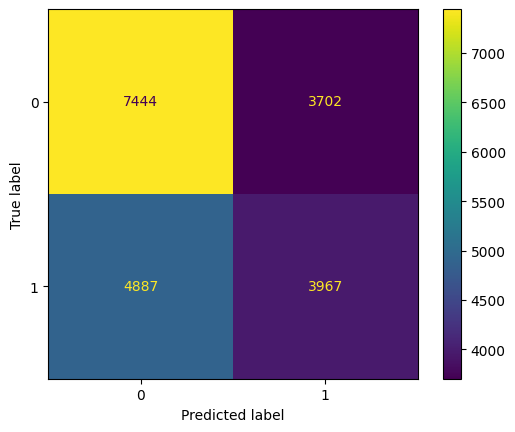

In [32]:
# confusion_matrix(y_train, y_train_pred)
ConfusionMatrixDisplay.from_predictions(y_classificacao, y_train_pred)

In [33]:
precision_score(y_classificacao, y_train_pred)

0.517277350371626

In [34]:
recall_score(y_classificacao, y_train_pred)

0.44804608086740455

In [35]:
f1_score(y_classificacao, y_train_pred)

0.480179144223204

In [36]:
from fairlearn.metrics import (
    MetricFrame,
    selection_rate,
    equalized_odds_difference,
    demographic_parity_difference,
    false_positive_rate,
    false_negative_rate,
)

df_fairness = X
classifier_pipeline = classifier_model1_pipeline

# False positive: quando a pessoa passou mas o modelo faz a previsão que não passou
# False negative: quando a pessoa não passou mas o modelo faz a previsão que passou.

metrics = {
    'Accuracy': accuracy_score,
    'Precision': precision_score,
    'Recall': recall_score,
    'Selection Rate (>= 500)': selection_rate,
    'False Positive Rate': false_positive_rate,
    'False Negative Rate': false_negative_rate,
}

metric_frame_raca = MetricFrame(
    metrics=metrics,
    y_true=y_classificacao,
    y_pred=y_train_pred,
    sensitive_features=df_fairness['cor_raca']
)

metric_frame_genero = MetricFrame(
    metrics=metrics,
    y_true=y_classificacao,
    y_pred=y_train_pred,
    sensitive_features=df_fairness['sexo']
)

# print(metric_frame_raca.by_group)
print(metric_frame_genero.by_group)

      Accuracy  Precision   Recall  Selection Rate (>= 500)  \
sexo                                                          
F     0.572958   0.458404  0.34987                 0.306474   
M     0.565603   0.585730  0.60168                 0.541622   

      False Positive Rate  False Negative Rate  
sexo                                            
F                0.277357              0.65013  
M                0.474637              0.39832  


In [37]:
dp_diff_raca = demographic_parity_difference(y_classificacao, y_train_pred, sensitive_features=df_fairness['cor_raca'])
eo_diff_raca = equalized_odds_difference(y_classificacao, y_train_pred, sensitive_features=df_fairness['cor_raca'])

print(f"Demographic Parity Difference: {dp_diff_raca:.4f}")
print(f"Equalized Odds Difference: {eo_diff_raca:.4f}")

Demographic Parity Difference: 0.3970
Equalized Odds Difference: 0.4087
